Dataset Shape: (3771, 26)
Class Distribution before SMOTE:
 binaryClass
0    3480
1     291
Name: count, dtype: int64

Applying SMOTE to training data...
Class Distribution after SMOTE:
 binaryClass
0    2783
1    2783
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:49:19] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- Model Performance Evaluation ---
Accuracy Score: 0.9947019867549669

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00       697
           1       0.94      1.00      0.97        58

    accuracy                           0.99       755
   macro avg       0.97      1.00      0.98       755
weighted avg       1.00      0.99      0.99       755



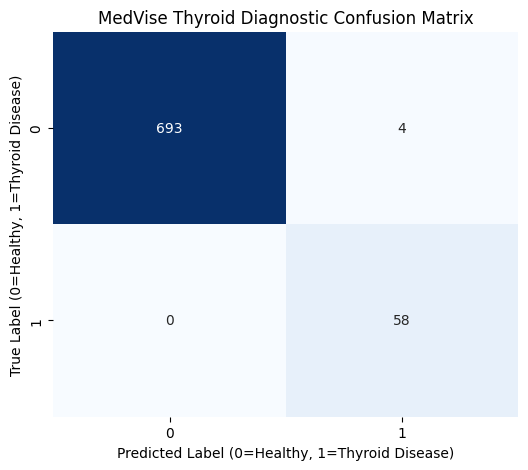

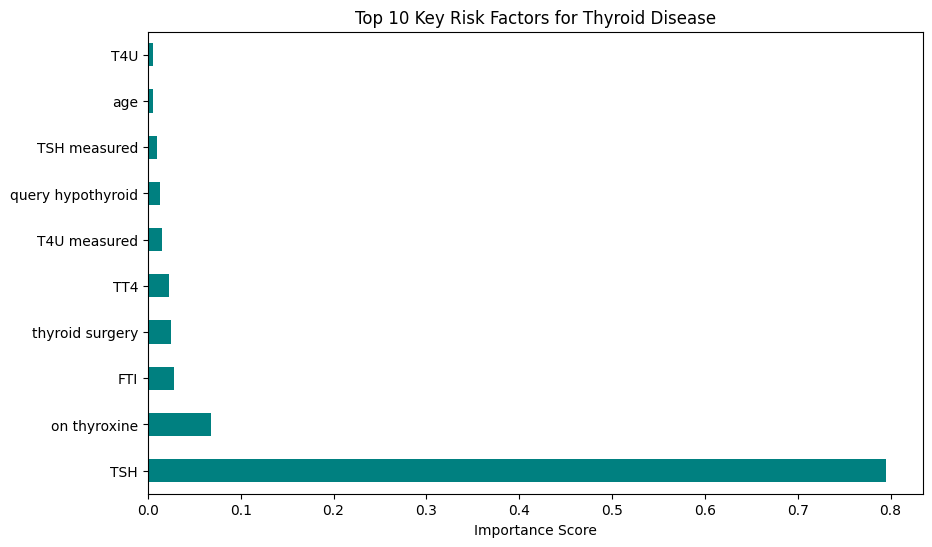

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

file_path = '/content/cleaned_dataset_Thyroid1.csv'
df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
print("Class Distribution before SMOTE:\n", df['binaryClass'].value_counts())

X = df.drop('binaryClass', axis=1)
y = df['binaryClass']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("\nApplying SMOTE to training data...")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Class Distribution after SMOTE:\n", pd.Series(y_train_resampled).value_counts())

model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

model.fit(X_train_resampled, y_train_resampled)

y_pred = model.predict(X_test)

print("\n--- Model Performance Evaluation ---")
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label (0=Healthy, 1=Thyroid Disease)')
plt.ylabel('True Label (0=Healthy, 1=Thyroid Disease)')
plt.title('MedVise Thyroid Diagnostic Confusion Matrix')
plt.show()

importances = model.feature_importances_
feature_names = X.columns
feat_importances = pd.Series(importances, index=feature_names)

plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Key Risk Factors for Thyroid Disease')
plt.xlabel('Importance Score')
plt.show()

Removed 3854 duplicate rows.

Training CatBoost Model...
0:	test: 0.9641644	best: 0.9641644 (0)	total: 169ms	remaining: 2m 49s
100:	test: 0.9778340	best: 0.9778340 (100)	total: 13.1s	remaining: 1m 56s
200:	test: 0.9781506	best: 0.9781567 (191)	total: 21.2s	remaining: 1m 24s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9782046935
bestIteration = 247

Shrink model to first 248 iterations.

--- Refined Model Performance ---
Accuracy: 0.8968
ROC-AUC: 0.9782

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.89      0.94     17534
           1       0.46      0.92      0.61      1696

    accuracy                           0.90     19230
   macro avg       0.72      0.91      0.78     19230
weighted avg       0.94      0.90      0.91     19230



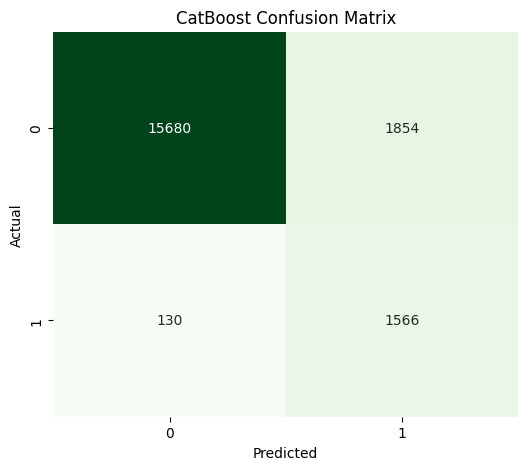


Generating SHAP Explanations...


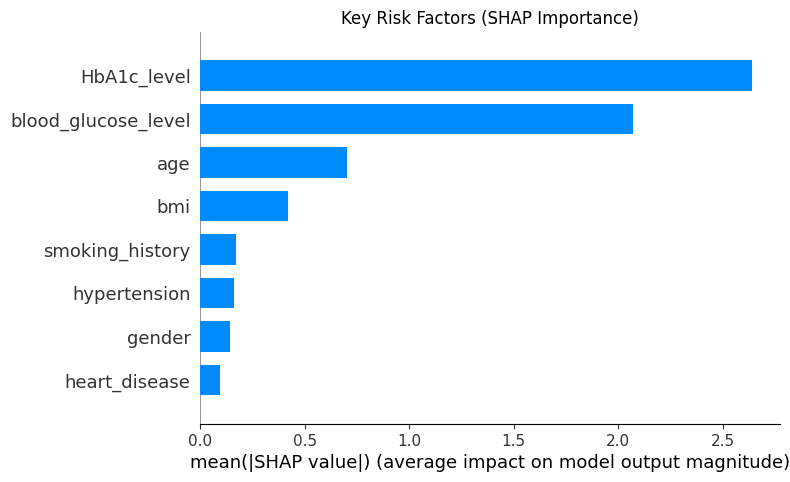

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from catboost import CatBoostClassifier, Pool
import shap

file_path = '/diabetes_prediction_dataset.csv'
df = pd.read_csv(file_path)

initial_rows = len(df)
df = df.drop_duplicates()
print(f"Removed {initial_rows - len(df)} duplicate rows.")

categorical_features = ['gender', 'smoking_history']

X = df.drop('diabetes', axis=1)
y = df['diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    cat_features=categorical_features,
    auto_class_weights='Balanced',
    verbose=100,
    early_stopping_rounds=50,
    eval_metric='AUC'
)

print("\nTraining CatBoost Model...")
model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    use_best_model=True
)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("\n--- Refined Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('CatBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nGenerating SHAP Explanations...")
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Key Risk Factors (SHAP Importance)")
plt.show()

✅ Dataset loaded successfully.
✅ Data processed. Training samples: 1347
⚙️  Training XGBoost Model...
✅ Training Complete.

🏆 Model Accuracy: 89.08%

Detailed Classification Report:
                precision    recall  f1-score   support

       Healthy       0.88      0.88      0.88       112
  Mild Disease       0.86      0.83      0.84        69
Severe Disease       0.93      0.98      0.96        57

      accuracy                           0.89       238
     macro avg       0.89      0.90      0.90       238
  weighted avg       0.89      0.89      0.89       238



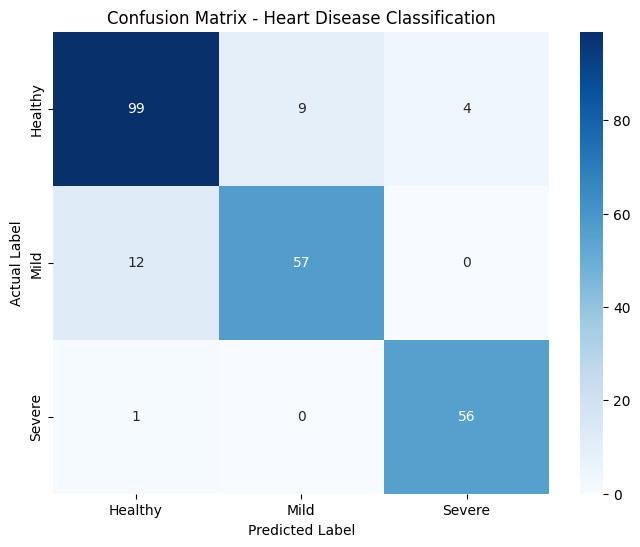


✅ SHAP values generated for explainability.

💾 Model and Scaler saved successfully.


In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from imblearn.over_sampling import SMOTE

try:
    df = pd.read_csv("/heart_disease_multiclass_engineered.csv")
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: Dataset not found.")
    exit()

X = df.drop(['target', 'diagnosis_class', 'diagnosis_label'], axis=1)
y = df['diagnosis_class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"✅ Data processed. Training samples: {len(X_train_resampled)}")

model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='mlogloss'
)

print("⚙️  Training XGBoost Model...")
model.fit(X_train_resampled, y_train_resampled)
print("✅ Training Complete.")

y_pred = model.predict(X_test_scaled)

print("\n" + "="*40)
print(f"🏆 Model Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("="*40)
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Healthy', 'Mild Disease', 'Severe Disease']))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Mild', 'Severe'],
            yticklabels=['Healthy', 'Mild', 'Severe'])
plt.title('Confusion Matrix - Heart Disease Classification')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_scaled)
print("\n✅ SHAP values generated for explainability.")

joblib.dump(model, 'medvise_cardio_xgboost.pkl')
joblib.dump(scaler, 'medvise_scaler.pkl')
print("\n💾 Model and Scaler saved successfully.")

import joblib

# Export the Cardiology model
# Replace 'best_heart_model' with your actual variable name
joblib.dump(best_heart_model, 'cardiology_model.joblib')

# Export the Diabetes model
# Replace 'best_diabetes_model' with your actual variable name
joblib.dump(best_diabetes_model, 'diabetes_model.joblib')

# Export the Thyroid model
# Replace 'best_thyroid_model' with your actual variable name
joblib.dump(best_thyroid_model, 'thyroid_model.joblib')

print("Models successfully saved!")